**Problem definition**

The objective is to fit $\mathbf{v} = (v_x, v_y)$, a vector velocity field, on a 2D square domain. The objective function is the following:

\begin{align}
v_x(x,y) &= -6 \pi \sin(4 \pi x) \sin(6 \pi y) \\
v_y(x,y) &= -4 \pi \cos(4 \pi x) \cos(6 \pi y).
\end{align}

Note that, by introducing the stream function $\psi(x,y) = \sin(4 \pi x) \cos(6 \pi y)$, we get:

\begin{align}
v_x(x,y) &= \frac{\partial \psi}{\partial y}, \\
v_y(x,y) &= -\frac{\partial \psi}{\partial x}.
\end{align}

Therefore:

\begin{equation}
\nabla \cdot \mathbf{v} = 0.
\end{equation}

On randomly sampled training points $X_{train} = (x_i, y_i)_{1\leq i \leq N_{train}}$, the target velocity field is computed, and random gaussian noise is applied, to create the final target field $\mathbf{v}^*_{train}$.

It can be beneficial to include this prior knowledge inside a surrogate model, as we will demonstrate below. For this, two learning processes are presented. 

In the first one, a model $M_{\lambda}$ is trained to fit the desired field. Its prediction on the training set is denoted $\mathbf{v}_{pred, \lambda} = M_{\lambda}(X_{train}).$ To ensure that the model learns to predict divergence-free fields, we compute $\nabla \cdot \mathbf{v}_{pred, \lambda}$, the divergence of the predicted field $\mathbf{v}_{pred, \lambda}$, by automatic differentiation. The resulting loss, which the model is trained to minimize, is therefore:

\begin{equation}
\mathcal{L}_{\lambda} = \lVert \mathbf{v}_{pred, \lambda} - \mathbf{v}^*_{train} \rVert^2 + \lambda \lVert \nabla \cdot \mathbf{v}_{pred, \lambda} \rVert^2.
\end{equation}

This learning process is denoted as _Physics-Aware_ learning, where a soft constraint is applied to the model during training to shape its prediction toward suitable physical properties (here, divergence-free fields).

The hyperparameter $\lambda$ balances the contribution of the divergence penalty to the total loss. $\lambda = 0$ corresponds to a standard data-driven learning, with no further guiding of the model towards divergence-free predictions. These hyperparameters are usually challenging to select, as we can see in the Physics-Informed litterature. Here, we will train models with varying values of $\lambda$.

For the second process, the goal of a model $M_{guided}$ is not to fit the final velocity field directly, but rather to learn the stream function $\psi$. On the training set, the predicted scalar function is $\psi_{pred} = M_{guided}(X_{train})$. Then, the velocity field $\mathbf{v}_{pred, guided}$ is computed using automatic differentiation, based on the known relations:

\begin{align}
v_{pred, guided, x} &= \frac{\partial \psi_{pred}}{\partial y}, \\
v_{pred, guided, y} &= -\frac{\partial \psi_{pred}}{\partial x}.
\end{align}

This step ensures by construction that the predicted velocity is divergence-free. Therefore, the final loss is simply:

\begin{equation}
\mathcal{L}_{guided} = \lVert \mathbf{v}_{pred, guided} - \mathbf{v}^*_{train} \rVert^2.
\end{equation}

After training, the models are evaluated on an independent validation set. The train and validation losses are tracked, along with the divergence norms of the predicted fields.

In [ ]:
#| include: false
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from utils import *
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ============================================================================
# DATASET GENERATION
# ============================================================================

def generate_2d_dataset(n_samples=2000, domain_size=2.0):
    """
    Generate a 2D divergence-free vector field.
    We use a stream function psi(x,y) such that:
    v_x = dpsi/dy, v_y = -dpsi/dx
    This automatically satisfies div v = 0
    """
    # Generate random points in 2D space
    x = torch.rand(n_samples, 2) * domain_size - domain_size/2
    
    # Define a stream function: psi(x,y) = sin(4 pi x) * cos(6 pi y)
    # Then:
    # v_x = dpsi/dy = -6 pi sin(4 pi x) * sin(6 pi y)
    # v_y = -dpsi/dx = -4 pi cos(4 pi x) * cos(6 pi y)
    
    v_x = -6*torch.pi*torch.sin(4*torch.pi*x[:, 0]) * torch.sin(6 * torch.pi * x[:, 1])
    v_y = -4*torch.pi * torch.cos(4*torch.pi*x[:, 0]) * torch.cos(6*torch.pi*x[:, 1])
    
    # Add some noise
    noise = 0.1 * torch.randn_like(v_x)
    v_x += noise
    v_y += noise
    
    v = torch.stack([v_x, v_y], dim=1)
    
    return x, v

# Verify divergence is close to zero
def compute_divergence_2d(x, v):
    """Compute divergence numerically using finite differences"""
    eps = 1e-4
    divergence = torch.zeros(v.shape[0])
    
    for i in range(2):  # x and y dimensions
        x_plus = x.clone()
        x_plus[:, i] += eps
        x_minus = x.clone()
        x_minus[:, i] -= eps
        
        # Compute v at perturbed points
        if i == 0:  # x-derivative of v_x
            v_x_plus = -torch.sin(x_plus[:, 0]) * torch.sin(x_plus[:, 1])
            v_x_minus = -torch.sin(x_minus[:, 0]) * torch.sin(x_minus[:, 1])
            divergence += (v_x_plus - v_x_minus) / (2 * eps)
        else:  # y-derivative of v_y
            v_y_plus = -torch.cos(x_plus[:, 0]) * torch.cos(x_plus[:, 1])
            v_y_minus = -torch.cos(x_minus[:, 0]) * torch.cos(x_minus[:, 1])
            divergence += (v_y_plus - v_y_minus) / (2 * eps)
    
    return divergence.mean().item()


In [3]:
# ============================================================================
# MODELS DEFINITION
# ============================================================================

class SimpleNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[32, 64, 32], output_dim=2):
        super(SimpleNN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Tanh())
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


In [4]:
class WeakConstraint2D(SimpleNN):
    """Model with weak divergence constraint via loss penalty"""
    def __init__(self, hidden_dims=[32, 64, 32]):
        super(WeakConstraint2D, self).__init__(input_dim=2, hidden_dims=hidden_dims, output_dim=2)
    
    def compute_loss(self, x, v_true, lambda_div=1.0):
        v_pred = self.network(x)
        mse_loss = torch.mean((v_pred - v_true)**2)
        # Extract components
        v_x = v_pred[:, 0]
        v_y = v_pred[:, 1]
        
        # Compute dv_x/dx
        grad_vx = torch.autograd.grad(
            v_x.sum(), x, create_graph=True, retain_graph=True
        )[0]
        div_x = grad_vx[:, 0]
        
        # Compute dv_y/dy  
        grad_vy = torch.autograd.grad(
            v_y.sum(), x, create_graph=True, retain_graph=True
        )[0]
        div_y = grad_vy[:, 1]
        
        divergence = div_x + div_y
        div_loss = torch.mean(divergence**2)
        
        # Total loss
        total_loss = mse_loss + lambda_div * div_loss
        
        return total_loss, mse_loss, div_loss

In [5]:
class StrongConstraint2D(nn.Module):
    """Model with strong divergence constraint via stream function"""
    def __init__(self, hidden_dims=[32, 64, 32]):
        super(StrongConstraint2D, self).__init__()
        
        # Network predicts a scalar stream function psi
        layers = []
        prev_dim = 2
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Tanh())
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))  # Output: scalar potential
        self.network = nn.Sequential(*layers)
    
    def forward(self, x, create_graph=True):
        if not x.requires_grad:
            x = x.clone().requires_grad_(True)
        
        # Predict stream function psi
        psi = self.network(x)
        
        # Compute gradient of psi w.r.t x
        grad_psi = torch.autograd.grad(
            outputs=psi.sum(),
            inputs=x,
            create_graph=create_graph,
            retain_graph=create_graph  # Retain graph if we need to compute gradients
        )[0]
        
        # v_x = dpsi_dy, v_y = -dpsi_dx
        v_x = grad_psi[:, 1]
        v_y = -grad_psi[:, 0]
        
        v = torch.stack([v_x, v_y], dim=1)
        
        return v, psi
    
    def compute_velocity(self, x):
        """Compute velocity without gradient computation (for inference)"""
        # Create a version of x that requires grad for the computation
        x_with_grad = x.clone().requires_grad_(True)
        
        # Compute with create_graph=False to avoid building computation graph
        with torch.set_grad_enabled(True):  # Enable gradients for autograd.grad
            v, psi = self.forward(x_with_grad, create_graph=False)
        
        return v.detach() 
    
    def compute_divergence(self, x, batch_size=None):
        """Compute divergence of the predicted velocity field
        
        Note: This should be zero by construction for the strong constraint model.
        """
        if batch_size is None or batch_size >= x.shape[0]:
            # Compute all at once
            x = x.clone().requires_grad_(True)
            v, _ = self.forward(x, create_graph=True)
            
            v_x = v[:, 0]
            v_y = v[:, 1]
            
            # Compute gradients for divergence
            grad_vx = torch.autograd.grad(
                outputs=v_x.sum(),
                inputs=x,
                create_graph=False,
                retain_graph=True
            )[0]
            div_x = grad_vx[:, 0]
            
            grad_vy = torch.autograd.grad(
                outputs=v_y.sum(),
                inputs=x,
                create_graph=False,
                retain_graph=False
            )[0]
            div_y = grad_vy[:, 1]
            
            divergence = div_x + div_y
            div_loss = torch.mean(divergence**2)
            
            return div_loss.item()
        else:
            # Compute in batches to save memory
            n_samples = x.shape[0]
            total_div = 0.0
            n_batches = int(np.ceil(n_samples / batch_size))
            
            for i in range(n_batches):
                start = i * batch_size
                end = min(start + batch_size, n_samples)
                x_batch = x[start:end].clone().requires_grad_(True)
                
                v, _ = self.forward(x_batch, create_graph=True)
                
                v_x = v[:, 0]
                v_y = v[:, 1]
                
                # Compute gradients for divergence
                grad_vx = torch.autograd.grad(
                    outputs=v_x.sum(),
                    inputs=x_batch,
                    create_graph=False,
                    retain_graph=True
                )[0]
                div_x = grad_vx[:, 0]
                
                grad_vy = torch.autograd.grad(
                    outputs=v_y.sum(),
                    inputs=x_batch,
                    create_graph=False,
                    retain_graph=False
                )[0]
                div_y = grad_vy[:, 1]
                
                divergence = div_x + div_y
                batch_div = torch.mean(divergence**2).item()
                total_div += batch_div * (end - start)
            
            return total_div / n_samples

In [6]:
def train_simple(model, x_train, v_train, x_val, v_val, 
                 model_type='weak', n_epochs=300, lr=0.001, 
                 lambda_div=0.1, batch_size=64, verbose = True):
    
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    val_div_losses = []  # validation divergence
    
    x_train, v_train = x_train.to(device), v_train.to(device)
    x_val, v_val = x_val.to(device), v_val.to(device)
    
    n_samples = x_train.shape[0]
    
    for epoch in range(n_epochs):
        # Training
        indices = torch.randperm(n_samples)
        x_shuffled = x_train[indices]
        v_shuffled = v_train[indices]
        
        model.train()
        epoch_loss = 0
        n_batches = int(np.ceil(n_samples / batch_size))
        
        for batch_idx in range(n_batches):
            start = batch_idx * batch_size
            end = min(start + batch_size, n_samples)
            
            x_batch = x_shuffled[start:end]
            v_batch = v_shuffled[start:end]
            
            optimizer.zero_grad()
            
            if model_type == 'weak':
                x_batch = x_batch.requires_grad_(True)
                total_loss, mse_loss, div_loss = model.compute_loss(x_batch, v_batch, lambda_div)
            else:  # strong
                # For strong constraint, we need x to require grad
                x_batch_with_grad = x_batch.clone().requires_grad_(True)
                v_pred, _ = model(x_batch_with_grad, create_graph=True)
                total_loss = torch.mean((v_pred - v_batch)**2)
            
            total_loss.backward()
            optimizer.step()
            epoch_loss += total_loss.item()
        
        avg_train_loss = epoch_loss / n_batches
        
        # Validation
        model.eval()
        with torch.no_grad():
            if model_type == 'weak':
                v_val_pred = model.network(x_val)
                val_loss = torch.mean((v_val_pred - v_val)**2).item()
            else:  # strong
                v_val_pred = model.compute_velocity(x_val)
                val_loss = torch.mean((v_val_pred - v_val)**2).item()
        
        # Compute validation divergence
        if model_type == 'weak':
            with torch.set_grad_enabled(True):
                x_val_with_grad = x_val.clone().requires_grad_(True)
                v_pred = model.network(x_val_with_grad)
                
                v_x = v_pred[:, 0]
                v_y = v_pred[:, 1]
                
                grad_vx = torch.autograd.grad(
                    v_x.sum(), x_val_with_grad, create_graph=False, retain_graph=True
                )[0]
                grad_vy = torch.autograd.grad(
                    v_y.sum(), x_val_with_grad, create_graph=False, retain_graph=False
                )[0]
                
                divergence = grad_vx[:, 0] + grad_vy[:, 1]
                val_div_loss = torch.mean(divergence**2).item()
        else:  # strong
            val_div_loss = model.compute_divergence(x_val, batch_size=64)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_div_losses.append(val_div_loss)
        
        if verbose and ((epoch + 1) % 500 == 0):
            print(f"Epoch {epoch+1:3d}/{n_epochs}: "
                  f"Train Loss = {avg_train_loss:.4f}, "
                  f"Val Loss = {val_loss:.4f}, "
                  f"Val Div = {val_div_loss:.4e}")
    
    return train_losses, val_losses, val_div_losses

**Training and results**

In [7]:
#| include: false
# Generate training and validation data
x_train, v_train = generate_2d_dataset(2000)
x_val, v_val = generate_2d_dataset(500)

print("\n" + "="*60)
print("Training Weak Constraint Model (Divergence Penalty)")
print("="*60)

weak_model_2d = WeakConstraint2D(hidden_dims=[32, 64, 32])
weak_train_loss, weak_val_loss, weak_val_div = train_simple(
    weak_model_2d, x_train, v_train, x_val, v_val,
    model_type='weak', n_epochs=2500, lr=0.003, lambda_div=0.1
)

print("\n" + "="*60)
print("Training Strong Constraint Model (Stream Function)")
print("="*60)

strong_model_2d = StrongConstraint2D(hidden_dims=[32, 64, 32])
strong_train_loss, strong_val_loss, strong_val_div = train_simple(
    strong_model_2d, x_train, v_train, x_val, v_val,
    model_type='strong', n_epochs=2500, lr=0.003
)



Training Weak Constraint Model (Divergence Penalty)
Epoch 500/2500: Train Loss = 23.9131, Val Loss = 25.5059, Val Div = 3.5473e+00
Epoch 1000/2500: Train Loss = 3.2734, Val Loss = 3.8107, Val Div = 3.1925e+00
Epoch 1500/2500: Train Loss = 0.9225, Val Loss = 1.4043, Val Div = 2.1938e+00
Epoch 2000/2500: Train Loss = 0.5977, Val Loss = 1.2398, Val Div = 1.5850e+00
Epoch 2500/2500: Train Loss = 0.5923, Val Loss = 0.9137, Val Div = 1.1459e+00

Training Strong Constraint Model (Stream Function)
Epoch 500/2500: Train Loss = 33.3398, Val Loss = 32.9439, Val Div = 2.5075e-10
Epoch 1000/2500: Train Loss = 3.0014, Val Loss = 3.7957, Val Div = 8.5352e-10
Epoch 1500/2500: Train Loss = 0.4488, Val Loss = 0.6251, Val Div = 6.7668e-10
Epoch 2000/2500: Train Loss = 0.2518, Val Loss = 0.4619, Val Div = 7.2296e-10
Epoch 2500/2500: Train Loss = 0.2348, Val Loss = 0.3590, Val Div = 6.5137e-10


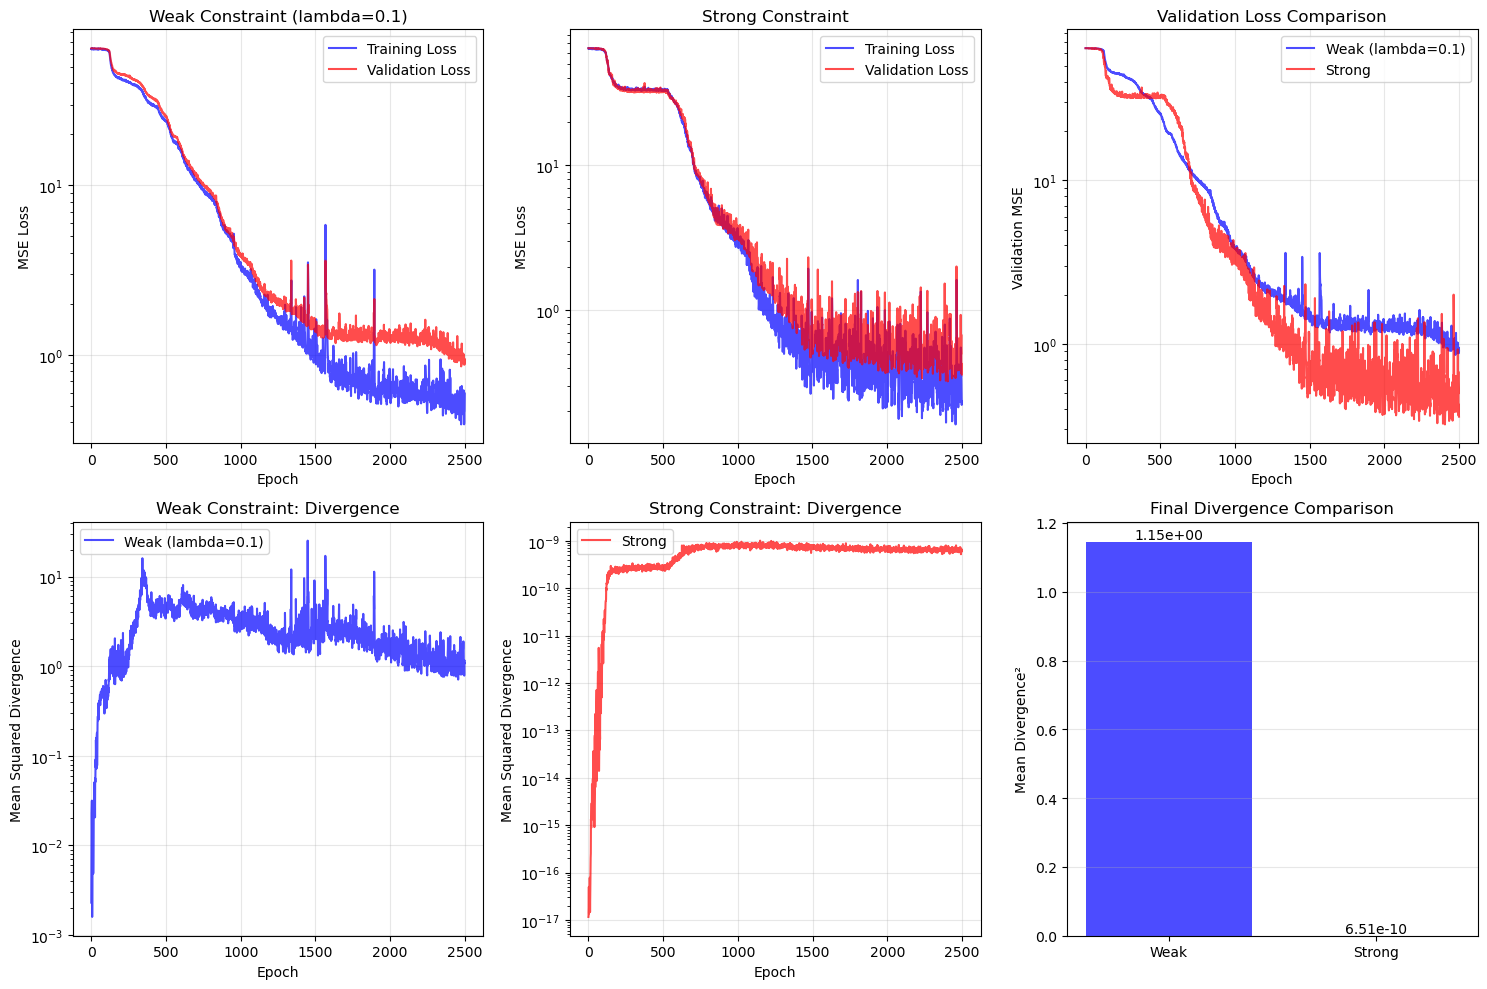

In [8]:
# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================
from utils import *

plot_training_curves([weak_train_loss, weak_val_loss, weak_val_div], 
                     [strong_train_loss, strong_val_loss, strong_val_div],
                     lambda_div=0.1)

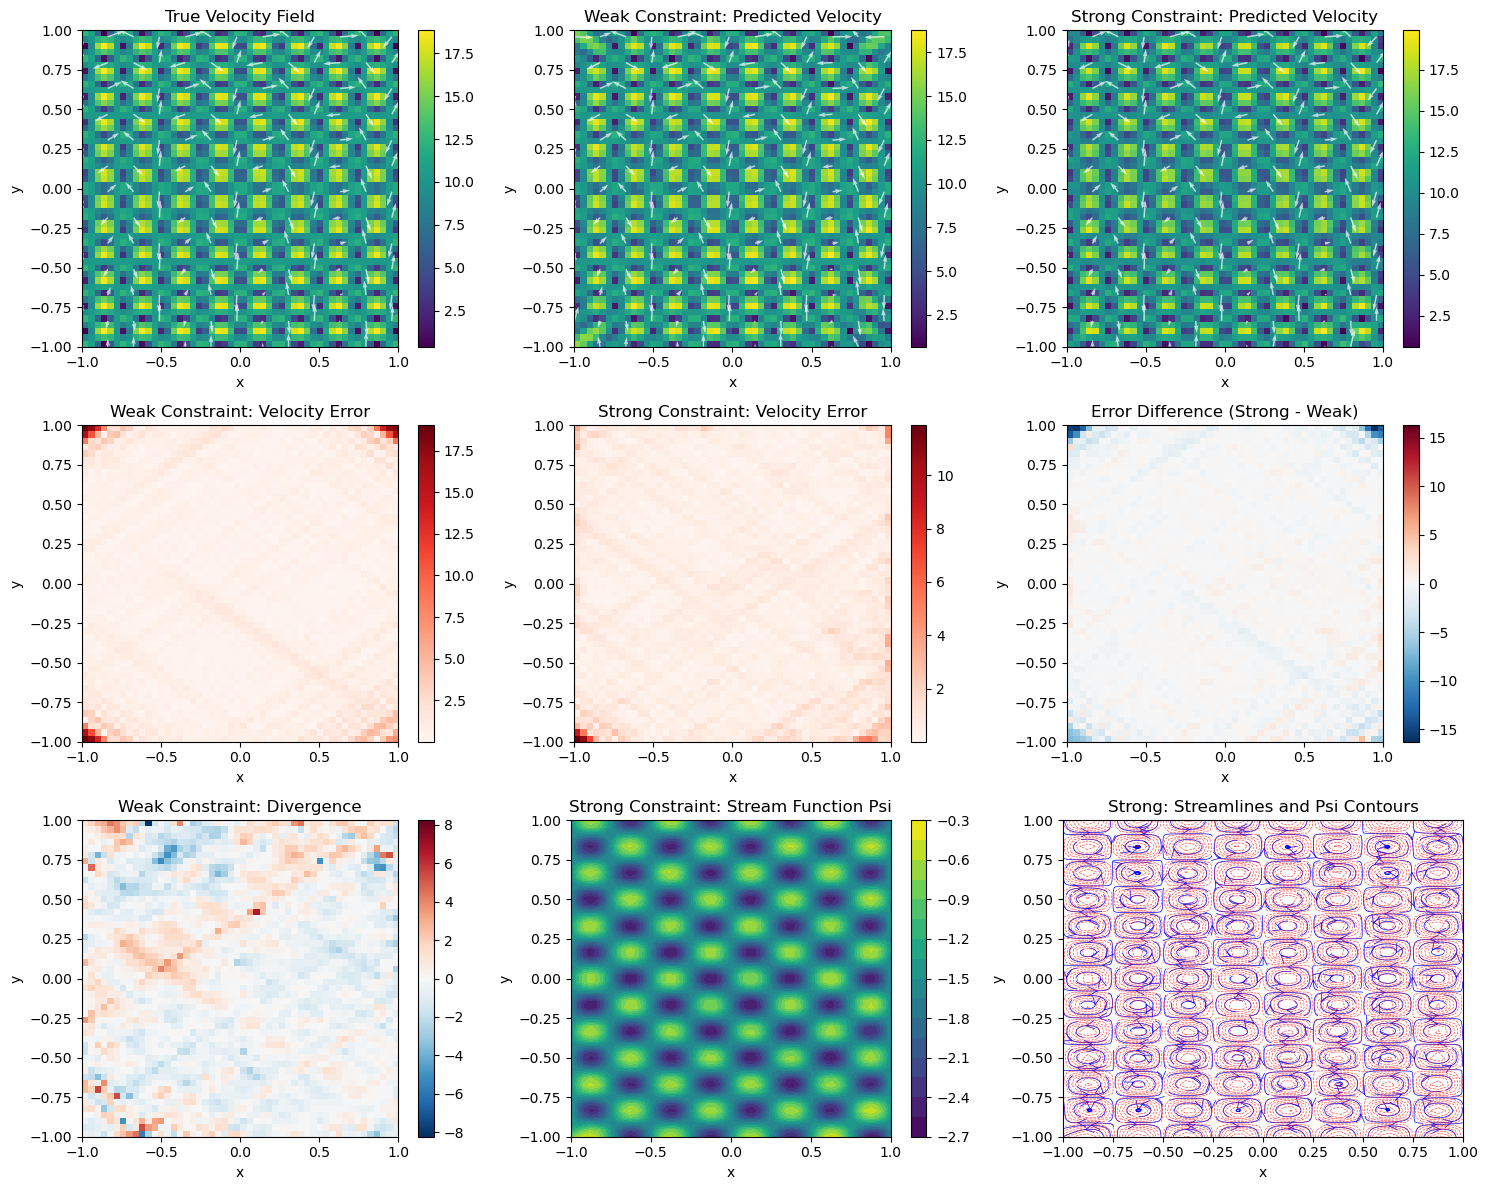

In [9]:

results = plot_velocity_fields(weak_model_2d, strong_model_2d, x_val,
                                extent=(-1, 1, -1, 1))


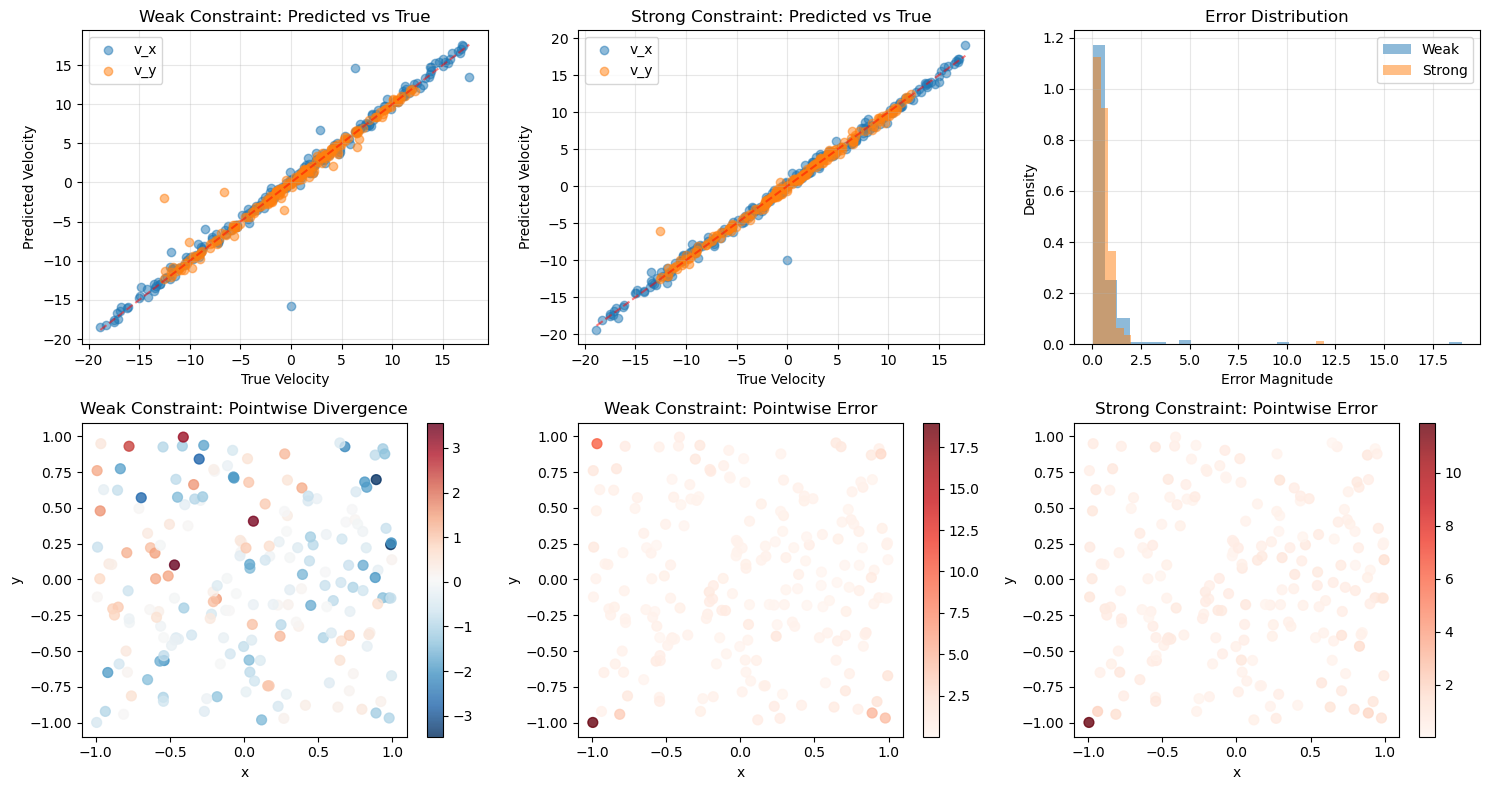

MODEL COMPARISON STATISTICS
Weak Constraint Model:
  MSE: 1.514752
  Std Error: 1.581516
  Max Error: 18.981909
  Mean |Divergence|: 7.663694e-01

Strong Constraint Model:
  MSE: 0.562070
  Std Error: 0.868654
  Max Error: 11.894469


In [10]:
#| output: false
# Sample some validation points
indices = np.random.choice(len(x_val), 200, replace=False)
plot_pointwise_comparison(weak_model_2d, strong_model_2d, 
                          x_val[indices].cpu().numpy())

The physics-guided model is roughly three times more accurate than the one with weak constraints. The physical consistency is also ensured through near-zero divergence. Now, we evaluate the performances as a function of the number of training points, for varying values of $\lambda$:

In [11]:
#| output: false
import gc 

torch.manual_seed(42)
np.random.seed(42)
nb_points = [200, 500, 1000, 2000, 3000]
epochs = [1500,1500, 1500, 2500, 2500]
learning_rates = [0.003,0.003,0.003, 0.003, 0.003]
weak_loss_0 = []
weak_div_0 = []
weak_train_0 = []
weak_loss_01 = []
weak_div_01 = []
weak_train_01 = []
weak_loss_1 = []
weak_div_1 = []
weak_train_1 = []
strong_loss = []
strong_div = []
strong_train = []

print("\n" + "="*60)
print("STARTING EXPERIMENT: ACCURACY VS NUMBER OF POINTS")
print("="*60)

# Create fixed validation set for fair comparison
print("\nCreating fixed validation dataset...")
x_val_fixed, v_val_fixed = generate_2d_dataset(1000)  # Fixed size
x_val_fixed = x_val_fixed.to(device)
v_val_fixed = v_val_fixed.to(device)
print(f"Fixed validation set: {x_val_fixed.shape}")

for i, pts in enumerate(nb_points):
    print(f"\n{'='*40}")
    print(f"Experiment {i+1}/{len(nb_points)}: {pts} training points")
    print(f"{'='*40}")
    gc.collect()
    x_train, v_train = generate_2d_dataset(pts)
    
    # Training Weak Constraint Model
    print("\nTraining Weak Constraint Model, Lambda = 0...")
    weak_model_2d = WeakConstraint2D(hidden_dims=[32,64,32])
    weak_train_loss, weak_val_loss, weak_val_div = train_simple(
        weak_model_2d, x_train, v_train, x_val, v_val,
        model_type='weak', n_epochs=epochs[i], lr=learning_rates[i], lambda_div=0., verbose=True
    )
    
    min_weak_loss_arg = np.argmin(weak_val_loss)
    min_weak_loss = weak_val_loss[min_weak_loss_arg]
    div_loss = weak_val_div[min_weak_loss_arg]
    train_loss = np.min(weak_train_loss)
    weak_loss_0.append(min_weak_loss)
    weak_train_0.append(train_loss)
    weak_div_0.append(div_loss)
    print(f"Min validation loss (Weak, lambda = 0): {min_weak_loss:.3f}")

    print("\nTraining Weak Constraint Model, Lambda = 0.1...")
    weak_model_2d = WeakConstraint2D(hidden_dims=[32,64,32])
    weak_train_loss, weak_val_loss, weak_val_div = train_simple(
        weak_model_2d, x_train, v_train, x_val, v_val,
        model_type='weak', n_epochs=epochs[i], lr=learning_rates[i], lambda_div=0.1, verbose=True
    )
    
    min_weak_loss_arg = np.argmin(weak_val_loss)
    min_weak_loss = weak_val_loss[min_weak_loss_arg]
    div_loss = weak_val_div[min_weak_loss_arg]
    train_loss = np.min(weak_train_loss)
    weak_loss_01.append(min_weak_loss)
    weak_train_01.append(train_loss)
    weak_div_01.append(div_loss)
    print(f"Min validation loss (Weak, Lambda = 0.1): {min_weak_loss:.3f}")

    print("\nTraining Weak Constraint Model, Lambda = 1...")
    weak_model_2d = WeakConstraint2D(hidden_dims=[32,64,32])
    weak_train_loss, weak_val_loss, weak_val_div = train_simple(
        weak_model_2d, x_train, v_train, x_val, v_val,
        model_type='weak', n_epochs=epochs[i], lr=learning_rates[i], lambda_div=1.0, verbose=True
    )
    
    min_weak_loss_arg = np.argmin(weak_val_loss)
    min_weak_loss = weak_val_loss[min_weak_loss_arg]
    div_loss = weak_val_div[min_weak_loss_arg]
    train_loss = np.min(weak_train_loss)
    weak_loss_1.append(min_weak_loss)
    weak_train_1.append(train_loss)
    weak_div_1.append(div_loss)
    print(f"Min validation loss (Weak, Lambda = 1): {min_weak_loss:.3f}")
    
    # Training Strong Constraint Model
    print("\nTraining Strong Constraint Model...")
    strong_model_2d = StrongConstraint2D(hidden_dims=[32,64,32])
    strong_train_loss, strong_val_loss, strong_val_div = train_simple(
        strong_model_2d, x_train, v_train, x_val, v_val,
        model_type='strong', n_epochs=epochs[i], lr=learning_rates[i], verbose=True
    )

    min_strong_loss_arg = np.argmin(strong_val_loss)
    min_strong_loss = strong_val_loss[min_strong_loss_arg]
    div_loss = strong_val_div[min_strong_loss_arg]
    train_loss = np.min(strong_train_loss)
    strong_loss.append(min_strong_loss)
    strong_train.append(train_loss)
    strong_div.append(div_loss)
    print(f"Min validation loss (Strong): {min_strong_loss:.3f}")



STARTING EXPERIMENT: ACCURACY VS NUMBER OF POINTS

Creating fixed validation dataset...
Fixed validation set: torch.Size([1000, 2])

Experiment 1/5: 200 training points

Training Weak Constraint Model, Lambda = 0...
Epoch 500/1500: Train Loss = 34.8583, Val Loss = 70.8263, Val Div = 1.5251e+03
Epoch 1000/1500: Train Loss = 22.4695, Val Loss = 74.5753, Val Div = 3.8839e+03
Epoch 1500/1500: Train Loss = 13.2807, Val Loss = 80.9774, Val Div = 8.4417e+03
Min validation loss (Weak, lambda = 0): 64.525

Training Weak Constraint Model, Lambda = 0.1...
Epoch 500/1500: Train Loss = 40.0196, Val Loss = 64.6630, Val Div = 5.0829e+01
Epoch 1000/1500: Train Loss = 34.4183, Val Loss = 60.2703, Val Div = 1.7515e+02
Epoch 1500/1500: Train Loss = 26.1941, Val Loss = 56.9076, Val Div = 5.4574e+02
Min validation loss (Weak, Lambda = 0.1): 56.763

Training Weak Constraint Model, Lambda = 1...
Epoch 500/1500: Train Loss = 53.0787, Val Loss = 62.7002, Val Div = 4.8094e+00
Epoch 1000/1500: Train Loss = 44.4

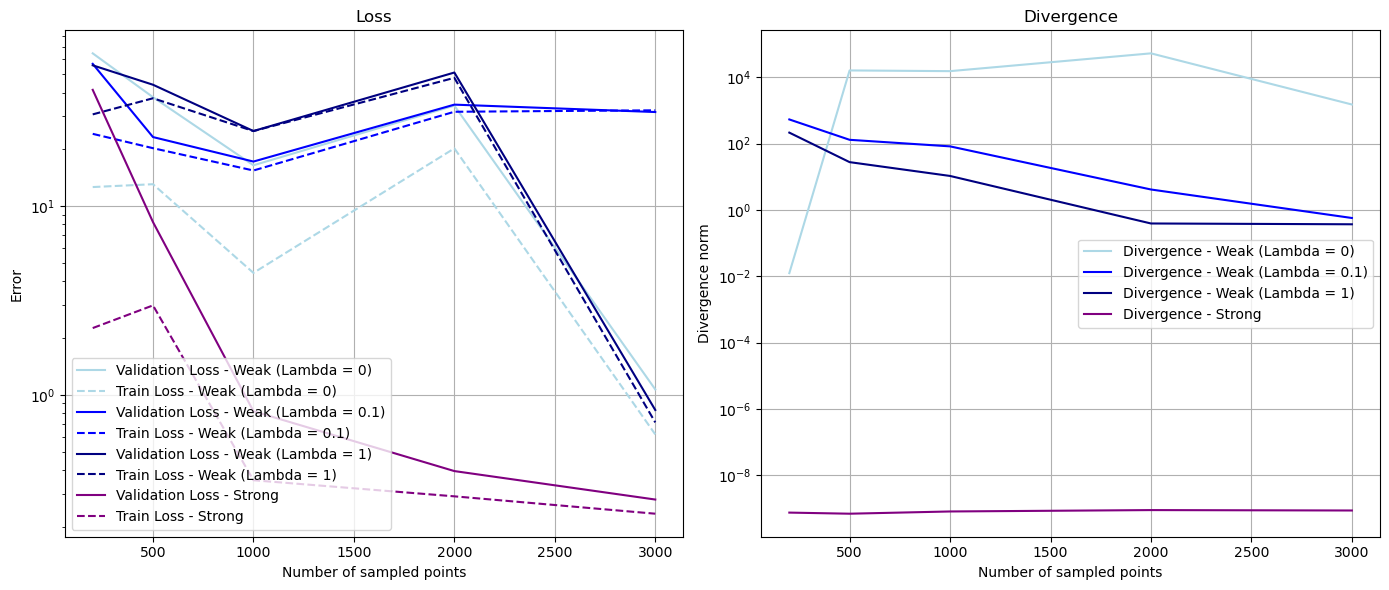

In [ ]:
legends = ["Weak (Lambda = 0)","Weak (Lambda = 0.1)", "Weak (Lambda = 1)", "Strong"]
results_val = [weak_loss_0, weak_loss_01, weak_loss_1, strong_loss]
results_div = [weak_div_0, weak_div_01, weak_div_1, strong_div]
results_train = [weak_train_0, weak_train_01, weak_train_1, strong_train]
colors = ["lightblue", "blue", "navy", "purple"]
### Plot the results
plot_multi_accuracy_vs_points(nb_points, results_val, results_div, results_train, legends, colors)

**Discussion**

The physics-guided models, with strong constraints, achieve overall a better accuracy. They are less data hungry, in the sense that they achieve a good accuracy with less points than simple data-aware models. As expected, they also achieve near-zero divergence and better control of the maximum error. For physics-aware models, which are easier to design, their performance heavily relies on the hyperparameter tuning in the loss function. Finally, for standard data driven models, they are more data-hungry, and they are prone to overfitting, as demonstrated by the big performance gap between train and validation loss.